# Vectorized micrograd — MNIST Demo

Ten-class handwritten digit classification on a 5 000-sample MNIST subset.  
Same engine as the checkerboard and spiral demos, but now with 784-dimensional
inputs, three hidden layers, and a proper train/test split.

Two data-loading paths are shown:

* **Method 1 — `sklearn.datasets.fetch_openml`** — one line, requires a network
  connection to `api.openml.org`.
* **Method 2 — pure `urllib` + IDX parser** — zero extra dependencies; reads the
  original binary files directly from a GitHub mirror of the NIST dataset.

Both return identical NumPy arrays. Toggle the `USE_SKLEARN` flag to pick one.

## Engine at a glance

`vect_engine.py` keeps the same interface as Karpathy's scalar `Value`
— `backward()`, `relu()`, operator overloads — but every node stores a full
NumPy array. The two pieces that make this non-trivial are:

* **`_unbroadcast`** — sums a broadcasted gradient back to the operand shape.
  When `b` has shape `(64,)` and `out = X @ W + b` has shape `(256, 64)`,
  the bias gradient must be summed over the batch dimension.
* **`__matmul__`** — explicit 2D backward
  (`dL/dX = dL/dY @ W.T`, `dL/dW = X.T @ dL/dY`).

With those two pieces in place the rest of the engine — add, mul, relu,
tanh, softmax_ce — is identical in structure to the scalar version.

## Building the MLP

`vect_nn.py` has two classes:

* **`Layer`** — weight matrix `W` (nin × nout) and bias `b` (nout,).  
  He initialisation: `W ~ N(0, sqrt(2/nin))`.
* **`MLP`** — stacks layers, applies the chosen activation between hidden
  layers, leaves the last layer linear.

MNIST inputs are 784-dimensional (28 × 28 pixels flattened).  
We use a `784 → 128 → 64 → 10` network — small enough to train in seconds
on NumPy alone, but expressive enough to reach ~93 % test accuracy.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vect_micrograd.vect_engine import Value
from vect_micrograd.vect_nn import MLP
from vect_micrograd.optim import Adam
from vect_micrograd.utils import one_hot, cross_entropy_loss, save_checkpoint, load_checkpoint

## Loading MNIST

### Method 1 — `sklearn.datasets.fetch_openml`

Scikit-learn ships a thin wrapper around the OpenML repository. It downloads
the dataset once and caches it on disk (`~/scikit_learn_data/` by default),
so subsequent runs are instant.

### Method 2 — pure `urllib` + IDX parser

The MNIST files are stored in a compact binary format called IDX. The header
encodes the magic number, the number of dimensions, and the size of each
dimension in big-endian 32-bit integers. Everything after the header is raw
uint8 pixel data.

The parser below reads the header with `struct.unpack`, then hands the rest
directly to `numpy.frombuffer` — no loops, no extra libraries.

In [35]:
USE_SKLEARN = False   # set True if api.openml.org is reachable

# ---------------------------------------------------------------------------
# Method 1 — sklearn / OpenML
# ---------------------------------------------------------------------------
if USE_SKLEARN:
    from sklearn.datasets import fetch_openml

    mnist        = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X_all_raw    = mnist.data.astype(float) / 255.0
    y_all        = mnist.target.astype(int)
    X_train_raw, y_train_raw = X_all_raw[:60000], y_all[:60000]
    X_test,      y_test      = X_all_raw[60000:], y_all[60000:]

# ---------------------------------------------------------------------------
# Method 2 — pure urllib + IDX binary parser (no extra dependencies)
# ---------------------------------------------------------------------------
else:
    import urllib.request, gzip, struct

    # GitHub mirror of the original NIST IDX files.
    _BASE  = 'https://raw.githubusercontent.com/fgnt/mnist/master/'
    _FILES = [
        ('X_train_raw', 'train-images-idx3-ubyte.gz'),
        ('y_train_raw', 'train-labels-idx1-ubyte.gz'),
        ('X_test',      't10k-images-idx3-ubyte.gz'),
        ('y_test',      't10k-labels-idx1-ubyte.gz'),
    ]

    def _fetch_idx(url):
        """Download and parse one IDX file (images or labels).

        IDX layout
        ----------
        bytes 0-3  : magic number  (big-endian uint32)
                     bits 8-15 = data type (0x08 = uint8)
                     bits 0-7  = number of dimensions (ndim)
        bytes 4..  : ndim dimension sizes (big-endian uint32 each)
        rest       : raw uint8 data, row-major
        """
        with urllib.request.urlopen(url) as resp:
            raw = gzip.decompress(resp.read())

        magic = struct.unpack('>I', raw[:4])[0]
        ndim  = magic & 0xFF
        dims  = struct.unpack('>' + 'I' * ndim, raw[4 : 4 + 4 * ndim])
        data  = np.frombuffer(raw[4 + 4 * ndim :], dtype=np.uint8)
        return data.reshape(dims)

    _loaded = {}
    for _name, _fname in _FILES:
        print(f'  fetching {_fname} ...')
        _loaded[_name] = _fetch_idx(_BASE + _fname)

    X_train_raw = _loaded['X_train_raw'].reshape(-1, 784).astype(float) / 255.0
    y_train_raw = _loaded['y_train_raw'].astype(int)
    X_test      = _loaded['X_test'].reshape(-1, 784).astype(float) / 255.0
    y_test      = _loaded['y_test'].astype(int)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test.shape}')
print(f'Labels: {np.unique(y_train_raw)}  pixel range: [{X_train_raw.min():.2f}, {X_train_raw.max():.2f}]')

  fetching train-images-idx3-ubyte.gz ...
  fetching train-labels-idx1-ubyte.gz ...
  fetching t10k-images-idx3-ubyte.gz ...
  fetching t10k-labels-idx1-ubyte.gz ...
Train: (60000, 784)  |  Test: (10000, 784)
Labels: [0 1 2 3 4 5 6 7 8 9]  pixel range: [0.00, 1.00]


## Balanced 5 000-sample subset

Training on all 60 000 samples with plain NumPy would take several minutes per
epoch. Instead we draw 500 examples per class (5 000 total), which gives a
representative, class-balanced training set that trains in seconds.

The full 10 000-sample test set is kept intact for evaluation — there's no
cost to evaluating on all of it since inference is a single forward pass.

Training subset : (5000, 784)  (balanced, 500 per class)
Test set        : (10000, 784)  (full)


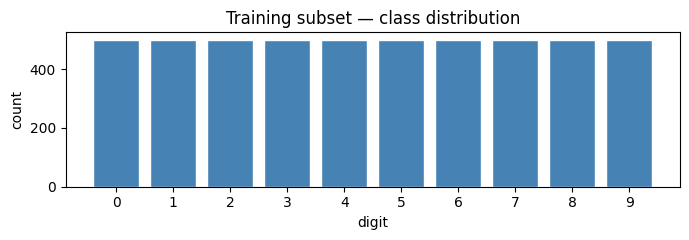

In [36]:
N_PER_CLASS = 500

rng = np.random.default_rng(0)

idx = np.concatenate([
    rng.choice(np.where(y_train_raw == c)[0], N_PER_CLASS, replace=False)
    for c in range(10)
])
rng.shuffle(idx)

X_train, y_train = X_train_raw[idx], y_train_raw[idx]
Y_train = one_hot(y_train, classes=10)

print(f'Training subset : {X_train.shape}  (balanced, {N_PER_CLASS} per class)')
print(f'Test set        : {X_test.shape}  (full)')

# Class balance check
counts = np.bincount(y_train)
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.bar(range(10), counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(10))
ax.set_xlabel('digit')
ax.set_ylabel('count')
ax.set_title('Training subset — class distribution')
plt.tight_layout()
plt.show()

## A look at the data

Each image is a 28 × 28 greyscale bitmap stored as a flat 784-element vector.
Reshaping to `(28, 28)` and calling `imshow` recovers the original digit.

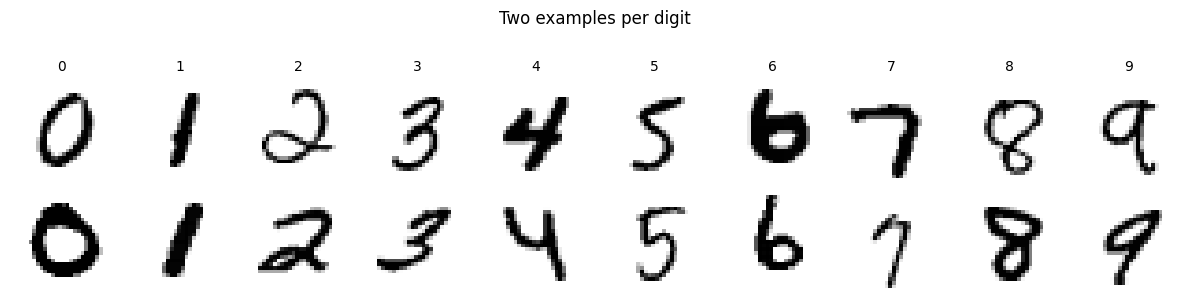

In [37]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))

for digit in range(10):
    examples = X_train[y_train == digit][:2]
    for row, img in enumerate(examples):
        axes[row, digit].imshow(img.reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=10)

plt.suptitle('Two examples per digit', y=1.02)
plt.tight_layout()
plt.show()

## Model

A three-layer MLP with ReLU activations:

```
784  →  128  →  64  →  10
       ReLU    ReLU    (linear logits)
```

The final layer produces raw logits; `softmax_ce` turns them into probabilities
and computes cross-entropy loss in one numerically stable fused operation.

In [38]:
np.random.seed(42)

model = MLP(784, [256, 128, 64, 10])

print(model)
print(f'Scalar parameters : {sum(p.data.size for p in model.parameters()):,}')
print(f'Value nodes       : {len(model.parameters())}  '
      f'(vs ~{sum(p.data.size for p in model.parameters()):,} in scalar micrograd)')

MLP of [Layer(784, 256), Layer(256, 128), Layer(128, 64), Layer(64, 10)]
Scalar parameters : 242,762
Value nodes       : 8  (vs ~242,762 in scalar micrograd)


## Training

Mini-batch Adam with a linear learning-rate decay to 10 % of the initial value.
The training loop mirrors the checkerboard demo:

1. Sample a random mini-batch.
2. Forward pass → loss.
3. Zero gradients, backward, optimizer step.
4. Track the best checkpoint (lowest *batch* loss).

Every 50 steps the full training-set loss and accuracy are printed so we can
follow convergence without noisy mini-batch estimates.

In [39]:
from vect_micrograd.optim import SGD, Adam, Lion
from vect_micrograd.utils import save_checkpoint, load_checkpoint, sample_batch

steps = 500
batch_size = 256

# optimizer = Adam(model.parameters(), lr=1e-3, total_steps=steps)
optimizer = Lion(model.parameters(), lr=1e-3, total_steps=steps, weight_decay=1e-2)

best_checkpoint, best_loss, best_step = None, float('inf'), -1
history = []   # (step, batch_loss, batch_acc, full_loss, full_acc)

for k in range(steps):
    Xb, Yb = sample_batch(X_train, Y_train, batch_size=256)
    
    batch_loss, batch_acc = cross_entropy_loss(model, Xb, Yb, alpha=1e-3)

    if batch_loss.item() < best_loss:
        best_loss = batch_loss.item()
        best_step = k
        best_checkpoint = save_checkpoint(model)

    optimizer.zero_grad()
    batch_loss.backward()
    optimizer.step(k)

    if k % 50 == 0:
        full_loss, full_acc = cross_entropy_loss(model, X_train, Y_train)
        history.append((k, batch_loss.item(), batch_acc, full_loss.item(), full_acc))
        print(f'step {k:3d}  '
              f'batch loss {batch_loss.item():.4f}  batch acc {batch_acc:.2%}  '
              f'full acc {full_acc:.2%}')

print(f'\nBest checkpoint at step {best_step}, batch loss {best_loss:.4f}')

step   0  batch loss 3.3275  batch acc 3.91%  full acc 15.68%
step  50  batch loss 0.8755  batch acc 93.75%  full acc 92.28%
step 100  batch loss 0.6791  batch acc 97.66%  full acc 96.94%
step 150  batch loss 0.5557  batch acc 99.22%  full acc 98.88%
step 200  batch loss 0.4225  batch acc 99.61%  full acc 99.36%
step 250  batch loss 0.3106  batch acc 99.22%  full acc 99.58%
step 300  batch loss 0.2348  batch acc 99.61%  full acc 99.66%
step 350  batch loss 0.1958  batch acc 100.00%  full acc 99.76%
step 400  batch loss 0.1718  batch acc 100.00%  full acc 99.86%
step 450  batch loss 0.1537  batch acc 100.00%  full acc 99.82%

Best checkpoint at step 497, batch loss 0.1459


## Training curves

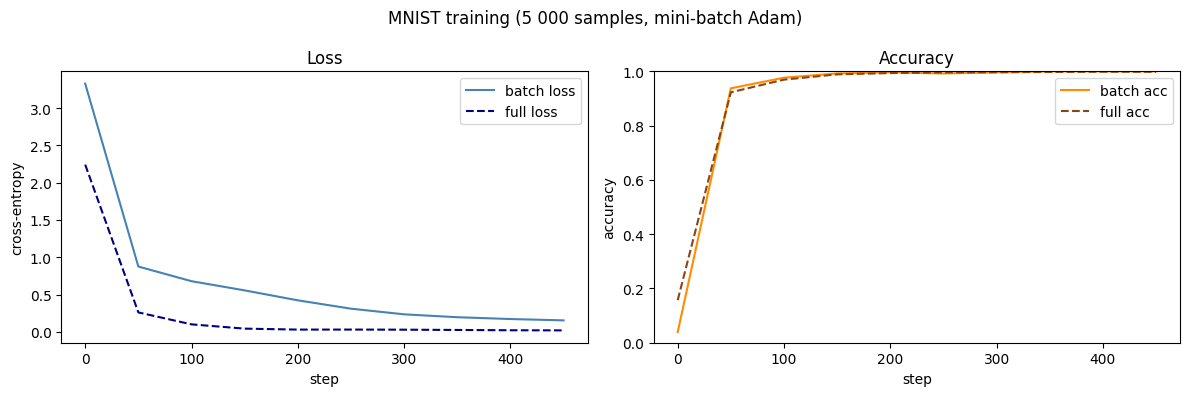

In [40]:
hist = np.array(history)   # columns: step, bloss, bacc, floss, facc
steps_logged = hist[:, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- loss ---
ax1.plot(steps_logged, hist[:, 1], color='steelblue',  label='batch loss')
ax1.plot(steps_logged, hist[:, 3], color='navy',       label='full loss', linestyle='--')
ax1.set_xlabel('step')
ax1.set_ylabel('cross-entropy')
ax1.set_title('Loss')
ax1.legend()

# --- accuracy ---
ax2.plot(steps_logged, hist[:, 2], color='darkorange', label='batch acc')
ax2.plot(steps_logged, hist[:, 4], color='saddlebrown',label='full acc',  linestyle='--')
ax2.set_xlabel('step')
ax2.set_ylabel('accuracy')
ax2.set_ylim(0, 1)
ax2.set_title('Accuracy')
ax2.legend()

plt.suptitle('MNIST training (5 000 samples, mini-batch Adam)')
plt.tight_layout()
plt.show()

## Test-set evaluation

Restore the best checkpoint and run a single forward pass over the full
10 000-sample test set.  No loops — the vectorized engine handles the whole
batch in one matmul per layer.

In [41]:
load_checkpoint(model, best_checkpoint)

test_logits = model(Value(X_test))
test_preds  = test_logits.data.argmax(axis=1)
test_acc    = float((test_preds == y_test).mean())

print(f'Restored checkpoint from step {best_step}')
print(f'Test accuracy : {test_acc:.2%}  ({int(test_acc * len(y_test)):,} / {len(y_test):,} correct)')

Restored checkpoint from step 497
Test accuracy : 95.26%  (9,526 / 10,000 correct)


## Confusion matrix

Which digits does the model confuse most? The confusion matrix shows
predicted class (columns) vs. true class (rows).

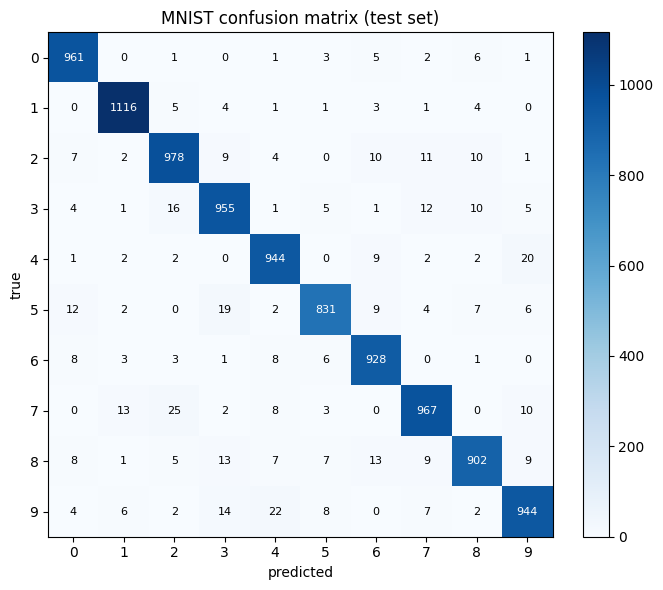

In [45]:
C = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test, test_preds):
    C[true, pred] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(C, cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('MNIST confusion matrix (test set)')

for i in range(10):
    for j in range(10):
        color = 'white' if C[i, j] > C.max() / 2 else 'black'
        ax.text(j, i, str(C[i, j]), ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.show()

## Hard cases — misclassified digits

A random sample of mistakes. These are the digits that fooled the network.

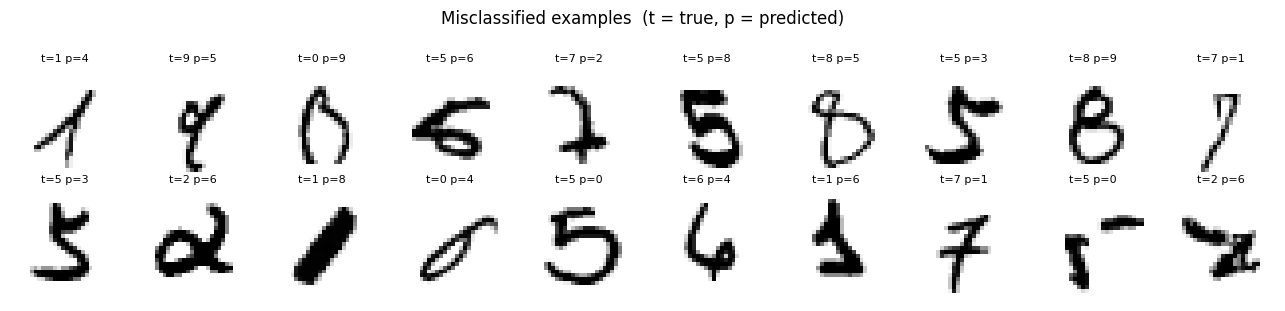

474 misclassifications out of 10000 test images


In [43]:
wrong_idx = np.where(test_preds != y_test)[0]
show      = np.random.default_rng(1).choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for ax, i in zip(axes.ravel(), show):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f't={y_test[i]} p={test_preds[i]}', fontsize=8)
    ax.axis('off')

plt.suptitle('Misclassified examples  (t = true, p = predicted)', y=1.02)
plt.tight_layout()
plt.show()

print(f'{len(wrong_idx)} misclassifications out of {len(y_test)} test images')

## Per-class accuracy

Class-level accuracy surfaces which digits are harder to classify.

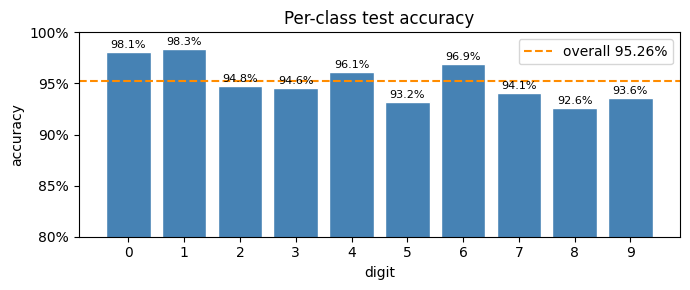

In [44]:
per_class = [
    float((test_preds[y_test == c] == c).mean())
    for c in range(10)
]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(range(10), per_class, color='steelblue', edgecolor='white')
ax.set_xticks(range(10))
ax.set_ylim(0.8, 1.0)
ax.set_xlabel('digit')
ax.set_ylabel('accuracy')
ax.set_title('Per-class test accuracy')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.axhline(test_acc, color='darkorange', linestyle='--', label=f'overall {test_acc:.2%}')
ax.legend()

for bar, v in zip(bars, per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
            f'{v:.1%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()